In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [2]:
df = pd.read_csv("/content/creditcard.csv")

In [4]:
print(df.head())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0     0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1     0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2     1 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3     1 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4     2 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11959 entries, 0 to 11958
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    11959 non-null  int64  
 1   V1      11959 non-null  float64
 2   V2      11959 non-null  float64
 3   V3      11959 non-null  float64
 4   V4      11959 non-null  float64
 5   V5      11959 non-null  float64
 6   V6      11959 non-null  float64
 7   V7      11959 non-null  float64
 8   V8      11959 non-null  float64
 9   V9      11959 non-null  float64
 10  V10     11959 non-null  float64
 11  V11     11959 non-null  float64
 12  V12     11959 non-null  float64
 13  V13     11959 non-null  float64
 14  V14     11959 non-null  float64
 15  V15     11959 non-null  float64
 16  V16     11959 non-null  float64
 17  V17     11959 non-null  float64
 18  V18     11959 non-null  float64
 19  V19     11959 non-null  float64
 20  V20     11958 non-null  float64
 21  V21     11958 non-null  float64
 22

In [6]:
print(df.isnull().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       1
V21       1
V22       1
V23       1
V24       1
V25       1
V26       1
V27       1
V28       1
Amount    1
Class     1
dtype: int64


In [7]:
print(df.describe())

               Time            V1            V2            V3            V4  \
count  11959.000000  11959.000000  11959.000000  11959.000000  11959.000000   
mean    8009.996822     -0.216230      0.277097      0.889505      0.282606   
std     6204.332248      1.583914      1.308884      1.331824      1.478162   
min        0.000000    -27.670569    -34.607649    -22.804686     -4.657545   
25%     2542.000000     -0.978944     -0.261503      0.417186     -0.622456   
50%     6662.000000     -0.340742      0.256346      0.951223      0.213029   
75%    12382.000000      1.161273      0.883626      1.613678      1.159141   
max    20642.000000      1.960497      9.092123      4.101716     11.927512   

                 V5            V6            V7            V8            V9  \
count  11959.000000  11959.000000  11959.000000  11959.000000  11959.000000   
mean      -0.086585      0.139986     -0.121943     -0.048727      0.911579   
std        1.191776      1.306285      1.153899    

In [8]:
df = df.dropna()

In [9]:
print("Shape after cleaning:", df.shape)

Shape after cleaning: (11958, 31)


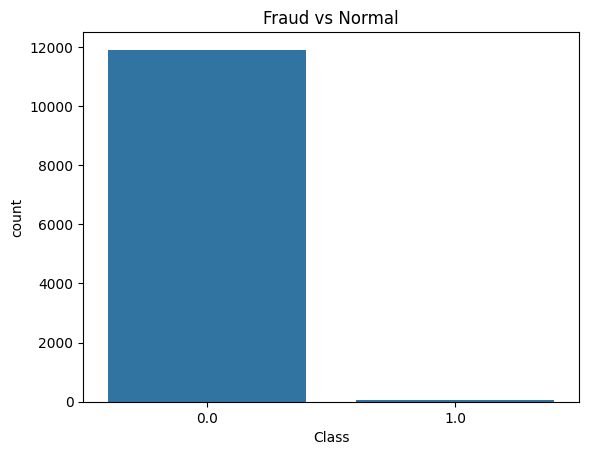

In [11]:
# Class distribution
sns.countplot(x='Class', data=df)
plt.title("Fraud vs Normal")
plt.show()

In [12]:
# Fraud percentage
print(df['Class'].value_counts(normalize=True))

Class
0.0    0.995651
1.0    0.004349
Name: proportion, dtype: float64


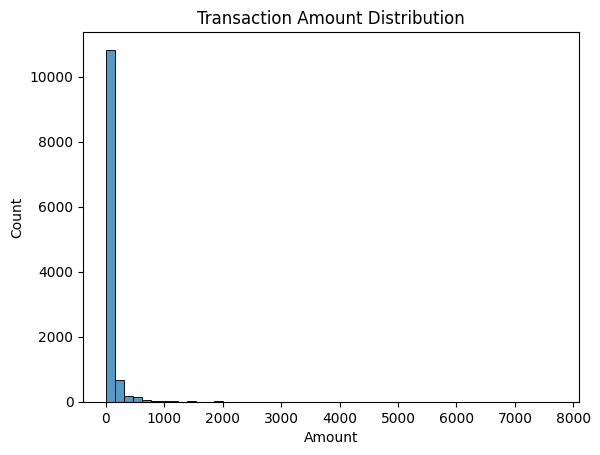

In [13]:
# Amount distribution
sns.histplot(df['Amount'], bins=50)
plt.title("Transaction Amount Distribution")
plt.show()

In [ ]:
df = df.drop('Time', axis=1)

In [15]:
# Split features and target
X = df.drop('Class', axis=1)
y = df['Class']

In [19]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

In [25]:
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

print("Train balance:", np.bincount(y_train))
print("Test balance:", np.bincount(y_test))

Train balance: [9524 9524]
Test balance: [2382   10]


In [26]:
rf_temp = RandomForestClassifier()
rf_temp.fit(X_train, y_train)

importances = rf_temp.feature_importances_
indices = np.argsort(importances)[-15:]

X_train = X_train[:, indices]
X_test = X_test[:, indices]

In [27]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(probability=True)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"\n{name}")
    print(classification_report(y_test, y_pred))

    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
    print("ROC-AUC:", auc)

    results[name] = auc


Logistic Regression
              precision    recall  f1-score   support

         0.0       1.00      0.99      1.00      2382
         1.0       0.41      0.90      0.56        10

    accuracy                           0.99      2392
   macro avg       0.70      0.95      0.78      2392
weighted avg       1.00      0.99      1.00      2392

ROC-AUC: 0.9640218303946263

Decision Tree
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      2382
         1.0       0.78      0.70      0.74        10

    accuracy                           1.00      2392
   macro avg       0.89      0.85      0.87      2392
weighted avg       1.00      1.00      1.00      2392

ROC-AUC: 0.8495801847187238

Random Forest
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      2382
         1.0       1.00      0.70      0.82        10

    accuracy                           1.00      2392
   macro avg       1.

In [28]:
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=3)
grid.fit(X_train, y_train)c

best_model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': 10, 'n_estimators': 50}


In [29]:
scores = cross_val_score(best_model, X_train, y_train, cv=5)
print("Cross-validation score:", scores.mean())

Cross-validation score: 0.9997900124652965


In [31]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

# Build ANN
ann = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compile model
ann.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train model
history = ann.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
477/477 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9634 - loss: 0.1216 - val_accuracy: 0.9961 - val_loss: 0.0221
Epoch 2/10
477/477 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9987 - loss: 0.0124 - val_accuracy: 1.0000 - val_loss: 0.0105
Epoch 3/10
477/477 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9990 - loss: 0.0083 - val_accuracy: 1.0000 - val_loss: 0.0046
Epoch 4/10
477/477 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9990 - loss: 0.0065 - val_accuracy: 1.0000 - val_loss: 0.0037
Epoch 5/10
477/477 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9993 - loss: 0.0054 - val_accuracy: 1.0000 - val_loss: 0.0042
Epoch 6/10
477/477 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9994 - loss: 0.0044 - val_accuracy: 1.0000 - val_loss: 0.0019
Epoch 7/10
477/477 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9995 - loss: 0.0039 - val_accuracy: 1.0000 - val_loss: 0.0015
Epoch 8/10
477/477 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9997 - loss: 0.0033 - val_accuracy: 1.

In [32]:
from sklearn.metrics import classification_report, roc_auc_score

# Predictions
y_pred_ann = (ann.predict(X_test) > 0.5).astype(int)

print("ANN Model Performance")
print(classification_report(y_test, y_pred_ann))

# ROC-AUC
y_prob_ann = ann.predict(X_test)
print("ANN ROC-AUC:", roc_auc_score(y_test, y_prob_ann))

75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
ANN Model Performance
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      2382
         1.0       0.89      0.80      0.84        10

    accuracy                           1.00      2392
   macro avg       0.94      0.90      0.92      2392
weighted avg       1.00      1.00      1.00      2392

75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
ANN ROC-AUC: 0.9022250209907641


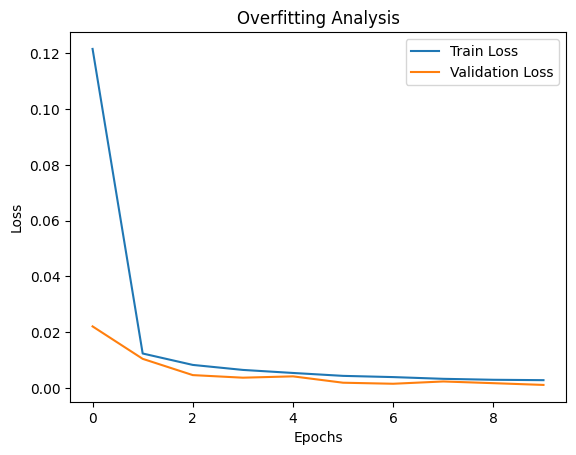

In [33]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Overfitting Analysis")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [34]:
import pickle

# Save final trained model (Random Forest)
pickle.dump(best_model, open("model.pkl", "wb"))

# Save scaler
pickle.dump(scaler, open("scaler.pkl", "wb"))

# Save selected feature indices
pickle.dump(indices, open("features.pkl", "wb"))

print(" Model files saved successfully!")

 Model files saved successfully!


In [39]:
from google.colab import files

files.download("model.pkl")
files.download("scaler.pkl")
files.download("features.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 74.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 57.7 MB/s eta 0:00:00


In [36]:
%%writefile app.py
import streamlit as st
import numpy as np
import pickle

model = pickle.load(open("model.pkl", "rb"))
scaler = pickle.load(open("scaler.pkl", "rb"))
indices = pickle.load(open("features.pkl", "rb"))

st.title("Fraud Detection")

input_data = st.text_input("Enter values")

if st.button("Predict"):
    values = np.array([float(i) for i in input_data.split(",")]).reshape(1, -1)
    values = scaler.transform(values)
    values = values[:, indices]

    pred = model.predict(values)

    if pred[0] == 1:
        st.write("Fraud")
    else:
        st.write("Legit")

Writing app.py


In [ ]:
from pyngrok import ngrok
!streamlit run app.py &

public_url = ngrok.connect(port=8501)
print(public_url)




  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.150.178.187:8501

